# Semantic Search Engine - Analysis Notebook

This notebook covers:
1. Dataset exploration
2. Embedding space visualisation (PCA / t-SNE)
3. Semantic vs TF-IDF comparison
4. Latency benchmark
5. Discussion of results


In [1]:
import os
import sys

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sqlalchemy import text

from src.db import get_session
from src.search import semantic_search, TFIDFSearchEngine

sns.set_theme(style="whitegrid")

# Same embedding model used by the ingestion pipeline (src/embeddings/encoder.py)
# and by semantic search (src/search/semantic.py); read from .env so the
# notebook stays in sync if EMBEDDING_MODEL is ever changed there.
EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL", "all-MiniLM-L6-v2")

print("Imports OK")

Imports OK


## 1. Dataset Overview

In [2]:
with get_session() as session:
    total_docs = session.execute(text("SELECT COUNT(*) FROM documents")).scalar()
    total_embs = session.execute(text("SELECT COUNT(*) FROM embeddings")).scalar()
    # Alias metadata column to avoid collision with SQLAlchemy Row internals
    sample = session.execute(
        text("SELECT title, content, metadata AS doc_meta FROM documents LIMIT 5")
    ).fetchall()

print(f"Documents : {total_docs:,}")
print(f"Embeddings: {total_embs:,}")
print()
for row in sample:
    print(f"Title   : {row.title}")
    print(f"Category: {(row.doc_meta or {}).get('label', '?')}")
    print(f"Snippet : {(row.content or '')[:120]}...")
    print()

Documents : 10,000
Embeddings: 10,000

Title   : Wall St
Category: Business
Snippet : Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics,...

Title   : Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputat
Category: Business
Snippet : Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputat...

Title   : Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the ou
Category: Business
Snippet : Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the ou...

Title   : Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\flows from the
Category: Business
Snippet : Iraq Halts Oil Exports from Main Southern Pipeline (Reuters

## 2. Category Distribution

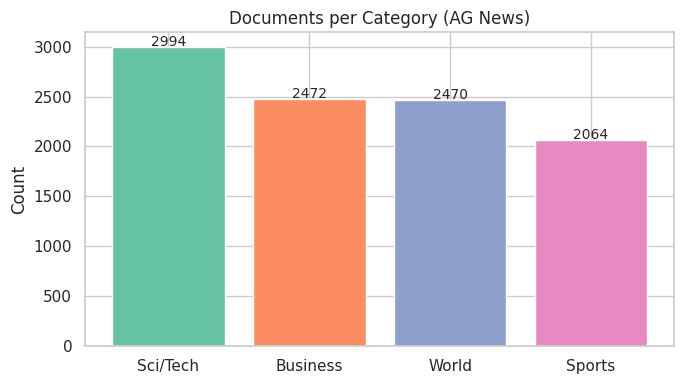

In [3]:
with get_session() as session:
    rows = session.execute(
        text(
            "SELECT metadata->>'label' AS label, COUNT(*) AS n "
            "FROM documents GROUP BY label ORDER BY n DESC"
        )
    ).fetchall()

labels = [r.label for r in rows]
counts = [r.n for r in rows]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, counts, color=sns.color_palette("Set2", len(labels)))
ax.set_title("Documents per Category (AG News)")
ax.set_ylabel("Count")
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        str(count),
        ha="center",
        fontsize=10,
    )
plt.tight_layout()
plt.savefig("../data/category_distribution.png", dpi=150)
plt.show()

## 3. Embedding Space Visualisation (PCA then t-SNE)

PCA explained variance (50 components): 58.1%


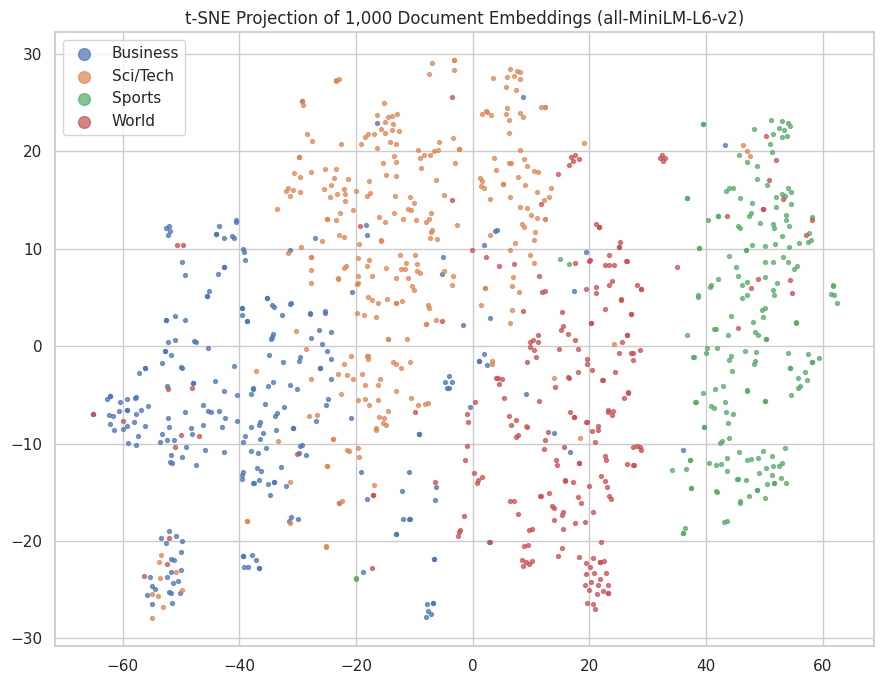

In [4]:
# Sample 1000 embeddings for visualisation.
#
# pgvector's `vector` type only gets decoded into a Python list automatically
# when SQLAlchemy's ORM Column type (pgvector.sqlalchemy.Vector, see
# src/db/models.py) handles the row. Raw text() queries bypass that, so
# e.embedding comes back as pgvector's own text representation, e.g.
# "[0.0123,-0.045,...]" -- a single string, not a list of floats. Casting to
# a Postgres array (`::real[]`) lets psycopg2's built-in array adapter parse
# it into an actual list of Python floats instead.
#
# We also filter by model_name (as src/search/semantic.py does) so the
# sample only mixes embeddings produced by the same model.
with get_session() as session:
    rows = session.execute(
        text("""
            SELECT e.embedding::real[] AS embedding, d.metadata->>'label' AS label
            FROM embeddings e
            JOIN documents d ON d.id = e.doc_id
            WHERE e.model_name = :model_name
            ORDER BY RANDOM()
            LIMIT 1000;
        """),
        {"model_name": EMBEDDING_MODEL},
    ).fetchall()

vecs = np.array([r.embedding for r in rows], dtype=np.float32)
labels_vis = [r.label for r in rows]

# Reduce to 50 dims with PCA before t-SNE (standard practice for speed + stability)
pca = PCA(n_components=50, random_state=42)
pca_vecs = pca.fit_transform(vecs)
explained = pca.explained_variance_ratio_.sum()
print(f"PCA explained variance (50 components): {explained:.1%}")

# t-SNE projection to 2D
# (scikit-learn >= 1.5 renamed the `n_iter` parameter to `max_iter`;
# requirements.txt pins scikit-learn>=1.4.0 with no upper bound, so a fresh
# install will pull a version where the old name no longer exists.)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_vecs = tsne.fit_transform(pca_vecs)

df_vis = pd.DataFrame({"x": tsne_vecs[:, 0], "y": tsne_vecs[:, 1], "label": labels_vis})

fig, ax = plt.subplots(figsize=(9, 7))
for lbl, grp in df_vis.groupby("label"):
    ax.scatter(grp.x, grp.y, label=lbl, s=8, alpha=0.7)
ax.set_title(f"t-SNE Projection of 1,000 Document Embeddings ({EMBEDDING_MODEL})")
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig("../data/tsne_embeddings.png", dpi=150)
plt.show()

## 4. Semantic vs TF-IDF - Query Comparison

In [5]:
from src.utils import compare_results

tfidf = TFIDFSearchEngine().build()

QUERIES = [
    "artificial intelligence breakthroughs",
    "financial markets interest rates",
    "space exploration new discoveries",
]

for q in QUERIES:
    sem = semantic_search(q, top_k=5)
    cls = tfidf.search(q, top_k=5)
    compare_results(sem, cls, q)

[TF-IDF] Built index: 10000 docs, vocab=97,842
[Encoder] Loading model: all-MiniLM-L6-v2


/home/amine/Documents/Projects/semantic-search-engine/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Query: artificial intelligence breakthroughs

Semantic (pgvector) Search - Query: artificial intelligence breakthroughs

...

Snippet: Seiko Epson Develops Micro Flying Robot Seiko Epson Corp. is developing a flying robot that looks like 
a miniature helicopter and is about the size of a giant bug. The company hope...

5. Score: 0.1382

Title: Redesigning Rockets: NASA Space Propulsion Finds a New Home (SPACE

Snippet: Redesigning Rockets: NASA Space Propulsion Finds a New Home (SPACE.com) SPACE.com - While the 
exploration of the Moon and other planets in our solar system is nbsp;exciting, the fi...

Overlap: 0 / 5 documents appear in both result sets.

## 5. Latency and Score Distribution

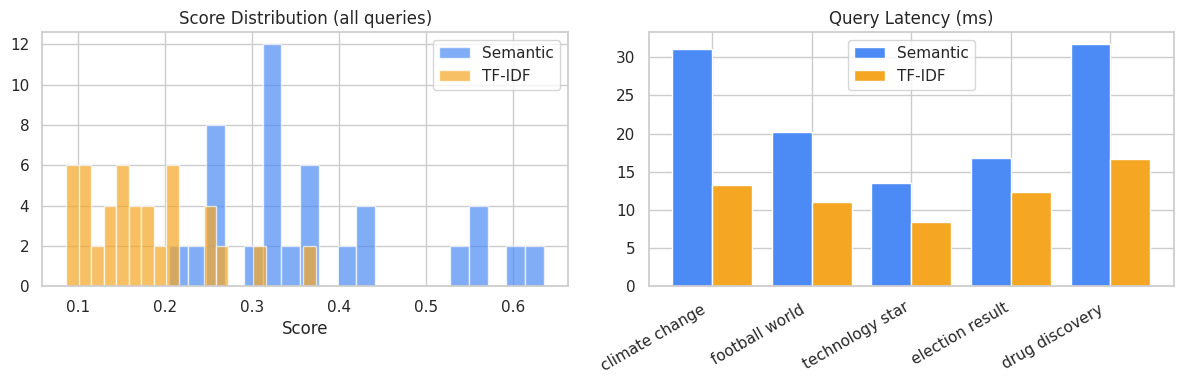

Average semantic latency : 22.7 ms
Average TF-IDF  latency  : 12.4 ms


In [6]:
import time

test_queries = [
    "climate change global warming",
    "football world cup championship",
    "technology startup funding",
    "election results president",
    "drug discovery pharmaceutical",
]

sem_scores, cls_scores, sem_times, cls_times = [], [], [], []

for q in test_queries:
    t0 = time.perf_counter()
    sem = semantic_search(q, top_k=10)
    sem_times.append(time.perf_counter() - t0)
    sem_scores.extend([r.score for r in sem])

    t0 = time.perf_counter()
    cls = tfidf.search(q, top_k=10)
    cls_times.append(time.perf_counter() - t0)
    cls_scores.extend([r.score for r in cls])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Score distributions
axes[0].hist(sem_scores, bins=20, alpha=0.7, label="Semantic", color="#4C8BF5")
axes[0].hist(cls_scores, bins=20, alpha=0.7, label="TF-IDF", color="#F5A623")
axes[0].set_title("Score Distribution (all queries)")
axes[0].set_xlabel("Score")
axes[0].legend()

# Latency comparison
x = range(len(test_queries))
axes[1].bar(
    [i - 0.2 for i in x],
    [t * 1000 for t in sem_times],
    0.4,
    label="Semantic",
    color="#4C8BF5",
)
axes[1].bar(
    [i + 0.2 for i in x],
    [t * 1000 for t in cls_times],
    0.4,
    label="TF-IDF",
    color="#F5A623",
)
axes[1].set_title("Query Latency (ms)")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels([q[:15] for q in test_queries], rotation=30, ha="right")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/comparison_chart.png", dpi=150)
plt.show()

print(f"Average semantic latency : {np.mean(sem_times) * 1000:.1f} ms")
print(f"Average TF-IDF  latency  : {np.mean(cls_times) * 1000:.1f} ms")